In [1]:
# complexity : O(n**2)

In [ ]:
import numpy as np

class LocalMiniBatchAP:
    def __init__(self, batch_size=50, damping=0.5, iters=20, seed=None):
        self.batch_size = batch_size
        self.damping = damping
        self.iters = iters
        self.rng = np.random.RandomState(seed)

    def _similarity(self, X):
        """computing the negative squared Euclidean distance between all pairs of rows in X.
        Returns −∥xi​−xj​∥^2
        """
        sq = np.sum(X**2, axis=1)
        return - (sq[:, None] + sq[None, :] - 2 * X @ X.T)

    def fit(self, X):
        n = X.shape[0]
        R = np.zeros((n, n)) # responsability
        A = np.zeros((n, n))  # availability

        for _ in range(self.iters):
            batch_idx = self.rng.choice(n, min(self.batch_size, n), replace=False)
            Xb = X[batch_idx]

            S = self._similarity(Xb)
            Rb = R[np.ix_(batch_idx, batch_idx)]
            Ab = A[np.ix_(batch_idx, batch_idx)]

            # Responsibility
            AS = Ab + S
            max_vals = np.max(AS, axis=1, keepdims=True)
            R_new = S - max_vals
            Rb = (1 - self.damping) * R_new + self.damping * Rb

            # Availability
            Rp = np.maximum(Rb, 0)
            np.fill_diagonal(Rp, np.diag(Rb))

            A_new = np.sum(Rp, axis=0)[None, :] - Rp
            A_new = np.minimum(A_new, 0)

            diag = np.sum(Rp, axis=0) - np.diag(Rp)
            np.fill_diagonal(A_new, diag)

            Ab = (1 - self.damping) * A_new + self.damping * Ab

            # Write back
            for i, ii in enumerate(batch_idx):
                for j, jj in enumerate(batch_idx):
                    R[ii, jj] = Rb[i, j]
                    A[ii, jj] = Ab[i, j]

        # Extract exemplars
        E = R + A
        labels = np.argmax(E, axis=1)
        exemplars = np.unique(labels)

        return X[exemplars]  # return prototypes

In [ ]:
class FederatedPrototypeAP:
    def __init__(self, n_rounds=10, max_prototypes=100):
        self.n_rounds = n_rounds
        self.max_prototypes = max_prototypes

    def _merge_prototypes(self, proto_list):
        # Stack all prototypes
        all_protos = np.vstack(proto_list)

        # Simple reduction: k-means-like pruning
        if len(all_protos) > self.max_prototypes:
            idx = np.random.choice(len(all_protos), self.max_prototypes, replace=False)
            return all_protos[idx]

        return all_protos

    def fit(self, client_data):
        global_prototypes = None

        for rnd in range(self.n_rounds):
            local_protos = []

            for X in client_data:
                # Augment with global prototypes (if available)
                if global_prototypes is not None:
                    X_aug = np.vstack([X, global_prototypes])
                else:
                    X_aug = X

                model = LocalMiniBatchAP()
                protos = model.fit(X_aug)

                local_protos.append(protos)

            # Server aggregation
            global_prototypes = self._merge_prototypes(local_protos)

        return global_prototypes

In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 9.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 10.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 10.3 MB/s eta 0:00:00a 0:00:01


Matplotlib is building the font cache; this may take a moment.


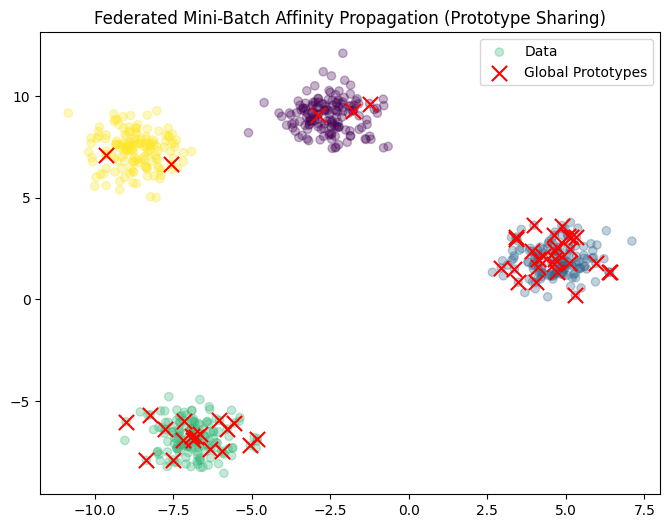

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# -----------------------------
# 1. Synthetic dataset
# -----------------------------
X, y_true = make_blobs(
    n_samples=600,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

# -----------------------------
# 2. Split into federated clients (non-IID)
# -----------------------------
def split_non_iid(X, y, n_clients=3):
    clients = []
    for i in range(n_clients):
        mask = (y % n_clients) == i
        clients.append(X[mask])
    return clients

client_data = split_non_iid(X, y_true, n_clients=3)

# -----------------------------
# 3. Local Mini-Batch AP
# -----------------------------
class LocalMiniBatchAP:
    def __init__(self, batch_size=50, damping=0.5, iters=15):
        self.batch_size = batch_size
        self.damping = damping
        self.iters = iters

    def _similarity(self, X):
        sq = np.sum(X**2, axis=1)
        return - (sq[:, None] + sq[None, :] - 2 * X @ X.T)

    def fit(self, X):
        n = X.shape[0]
        R = np.zeros((n, n))
        A = np.zeros((n, n))

        for _ in range(self.iters):
            idx = np.random.choice(n, min(self.batch_size, n), replace=False)
            Xb = X[idx]

            S = self._similarity(Xb)
            Rb = R[np.ix_(idx, idx)]
            Ab = A[np.ix_(idx, idx)]

            # Responsibility
            AS = Ab + S
            max_vals = np.max(AS, axis=1, keepdims=True)
            R_new = S - max_vals
            Rb = (1 - self.damping) * R_new + self.damping * Rb

            # Availability
            Rp = np.maximum(Rb, 0)
            np.fill_diagonal(Rp, np.diag(Rb))

            A_new = np.sum(Rp, axis=0)[None, :] - Rp
            A_new = np.minimum(A_new, 0)

            diag = np.sum(Rp, axis=0) - np.diag(Rp)
            np.fill_diagonal(A_new, diag)

            Ab = (1 - self.damping) * A_new + self.damping * Ab

            # write back
            for i, ii in enumerate(idx):
                for j, jj in enumerate(idx):
                    R[ii, jj] = Rb[i, j]
                    A[ii, jj] = Ab[i, j]

        E = R + A
        labels = np.argmax(E, axis=1)
        exemplars = np.unique(labels)

        return X[exemplars]


# -----------------------------
# 4. Federated Prototype AP
# -----------------------------
class FederatedPrototypeAP:
    def __init__(self, rounds=8, max_prototypes=50):
        self.rounds = rounds
        self.max_prototypes = max_prototypes

    def _merge(self, protos):
        all_p = np.vstack(protos)

        if len(all_p) > self.max_prototypes:
            idx = np.random.choice(len(all_p), self.max_prototypes, replace=False)
            return all_p[idx]
        return all_p

    def fit(self, client_data):
        global_protos = None

        for r in range(self.rounds):
            collected = []

            for X in client_data:
                if global_protos is not None:
                    X_aug = np.vstack([X, global_protos])
                else:
                    X_aug = X

                model = LocalMiniBatchAP()
                p = model.fit(X_aug)
                collected.append(p)

            global_protos = self._merge(collected)

        return global_protos


# -----------------------------
# 5. Run federated training
# -----------------------------
fed_model = FederatedPrototypeAP(rounds=10)
global_prototypes = fed_model.fit(client_data)

# -----------------------------
# 6. Visualization
# -----------------------------
plt.figure(figsize=(8, 6))

# plot all data
plt.scatter(X[:, 0], X[:, 1], c=y_true, alpha=0.3, label="Data")

# plot prototypes
plt.scatter(
    global_prototypes[:, 0],
    global_prototypes[:, 1],
    c="red",
    s=120,
    marker="x",
    label="Global Prototypes"
)

plt.title("Federated Mini-Batch Affinity Propagation (Prototype Sharing)")
plt.legend()
plt.show()

In [ ]:
# here: protoypes looks like potential cluster center, 

In [5]:
# to solve that, one can use post training methods to aggregate prototypes that are close enough within a cluster  into one main center

In [ ]:
from scipy.spatial.distance import pdist, squareform

D = squareform(pdist(global_prototypes))
threshold = 0.5

keep = []
for i in range(len(global_prototypes)):
    if not any(D[i, j] < threshold for j in keep):
        keep.append(i)

merged = global_prototypes[keep]